# Purpose

#### As there is no general analytical expression for volume of a union of spheres, we have to choose some way to integrate these volumes as accurately as possible.
#### The two easiest methods to implement are mesh/grid or monte carlo (MC) integration. There are more advanced methods with better efficiencies, however implementing these methods could be a project in it of itself.
#### Here we benchmark the performance of mesh and MC integration against analytical volumes for the case of single spheres and two-sphere unions, and show which integration method between the two performs better.

In [1]:
import numpy as np
from JDFTxFreeNrg.testing import test_double_sphere_volume, test_single_sphere_volume

##### First we test a single sphere volume accuracy.

##### (Note the teal error bars on the MC convergence plot give the 95% confidence interval of the MC simulation)

Using 237 theta/phi resolution for PyVista 1 spheres
Using 237 theta/phi resolution for PyVista 1 spheres
Using 750 theta/phi resolution for PyVista 1 spheres
Using 750 theta/phi resolution for PyVista 1 spheres
Using 2371 theta/phi resolution for PyVista 1 spheres
Using 2371 theta/phi resolution for PyVista 1 spheres
Using 3354 theta/phi resolution for PyVista 1 spheres
Using 3354 theta/phi resolution for PyVista 1 spheres


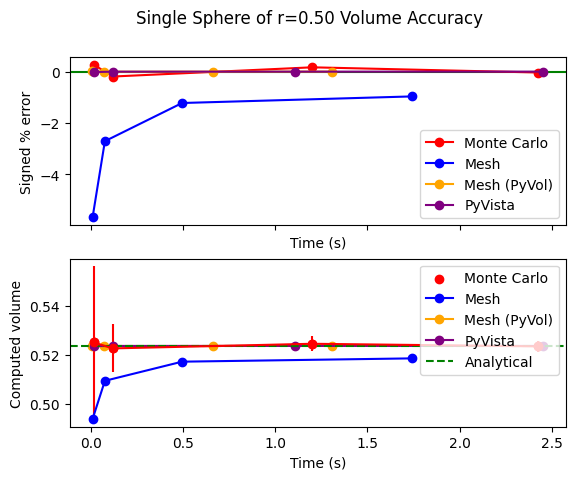

In [3]:
# For this notebook I'm explicitly providing the radii and sphere centers for reproducability.
# Change r/rs/center/centers to None for random generation
r = 0.5
center = np.zeros(3)
mesh_sample_scale = 150 # Since the mesh grid is vectorized, it takes about 150x less time per sample on my machine
nsampless = [1e3, 1e4, 1e5, 2e5]

test_single_sphere_volume(r=r, center=center, mesh_sample_scale=mesh_sample_scale, nsampless=nsampless, pyvol_sample_scale=4000.)

#### And double-sphere volume

Using 10 theta/phi resolution for PyVista 2 spheres
Using 10 theta/phi resolution for PyVista 2 spheres
Using 25 theta/phi resolution for PyVista 2 spheres
Using 25 theta/phi resolution for PyVista 2 spheres
Using 55 theta/phi resolution for PyVista 2 spheres
Using 55 theta/phi resolution for PyVista 2 spheres
Using 79 theta/phi resolution for PyVista 2 spheres
Using 79 theta/phi resolution for PyVista 2 spheres


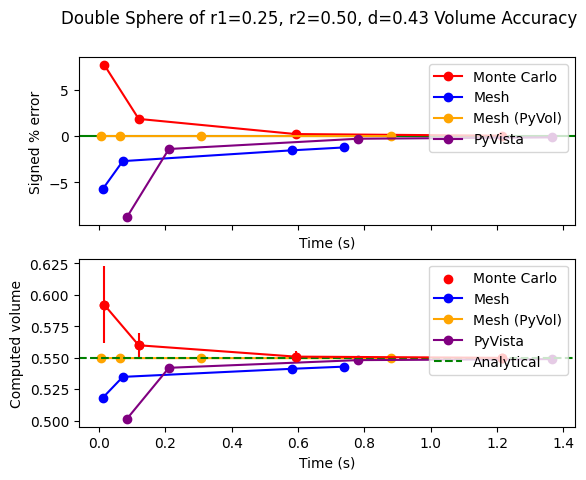

In [4]:
# For this notebook I'm explicitly providing the radii and sphere centers for reproducability.
# Change r/rs/center/centers to None for random generation
rs = [0.25, 0.5]
centers = [np.zeros(3), np.ones(3)*0.25]

test_double_sphere_volume(rs=rs, centers=centers, mesh_sample_scale=mesh_sample_scale, nsampless=nsampless, pyvol_sample_scale=4000.)

#### For both cases we see monte carlo integration outperforms mesh integration in terms of accuracy, however mesh integration is reproducable in its results and is gauranteed to be an enderestimate of the true value.